## Executive Report — Q3, Q4 and Q5

### Objetivo
Responder:
- 3. La segmentación de clientes.
- 4. La arquitectura lógica del recomendador en tiempo real.
- 5. La priorización geográfica para una tienda insignia física.

### Mensaje central
- La segmentación debe ser interpretable y operable.
- El recomendador debe apoyarse en perfil + historial + contexto.
- La expansión física debe priorizar ciudades con mayor escala y valor comercial.

### 1. Segmentación de clientes (Q3)

#### Hallazgo clave
La segmentación RFM original resultó más balanceada y útil como base operativa que la versión enriquecida actual.

#### Decisión metodológica
Se propone una segmentación híbrida en dos capas:
- segmento primario: ciclo de vida + valor
- flags secundarios: fricción, valor alto y riesgo de abandono

In [3]:
from pathlib import Path
import sys

import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.data.loaders import load_all_datasets
from src.analysis.site_selection import (
    build_city_sales_summary,
    add_city_priority_score,
)

In [5]:
TP_COLORS = {
    "blue_primary": "#2448A8",
    "blue_secondary": "#4C78E6",
    "blue_soft": "#6EC1E4",
    "yellow_accent": "#F2D22E",
    "gray_bg": "#F3F4F6",
    "gray_text": "#4B5563",
    "gray_muted": "#D1D5DB",
    "gray_dark": "#1F2937",
    "white": "#FFFFFF",
}

def fmt_pct(x, pos=None):
    return f"{x:.0%}"

def fmt_int(x, pos=None):
    return f"{x:,.0f}"

processed_dir = PROJECT_ROOT / "data" / "processed"

customer_360_features = pd.read_csv(processed_dir / "customer_360_features.csv")
customer_primary_segment_summary = pd.read_csv(processed_dir / "customer_primary_segment_summary.csv")
customer_flag_summary = pd.read_csv(processed_dir / "customer_flag_summary.csv")

In [6]:
bundle = load_all_datasets()

customers = bundle.customers.copy()
orders = bundle.orders.copy()
order_items = bundle.order_items.copy()

In [7]:
delivered_orders = orders.loc[orders["order_status"] == "delivered"].copy()

order_value = (
    order_items.groupby("order_id", as_index=False)
    .agg(
        order_revenue=("price", "sum"),
        freight_total=("freight_value", "sum"),
        n_items=("order_item_id", "count"),
    )
)

order_base = (
    delivered_orders
    .merge(order_value, on="order_id", how="inner", validate="one_to_one")
    .merge(customers, on="customer_id", how="left", validate="many_to_one")
)

In [8]:
city_summary = build_city_sales_summary(order_base)
city_priority = add_city_priority_score(city_summary)
top_city = city_priority.iloc[0].copy()

## 1.1 Comparación entre la segmentación base y la enriquecida

In [9]:
comparison_segments = pd.DataFrame({
    "model_version": [
        "RFM base",
        "Customer 360 enriched (initial)",
        "Production-ready segmentation"
    ],
    "key_message": [
        "Balanced and interpretable for marketing",
        "Useful for feature engineering, but unstable as final production taxonomy",
        "Operationally robust: primary segment + risk flags"
    ]
})

comparison_segments

,model_version,key_message
0,RFM base,Balanced and interpretable for marketing
1,Customer 360 enriched (initial),"Useful for feature engineering, but unstable a..."
2,Production-ready segmentation,Operationally robust: primary segment + risk f...


In [10]:
production_taxonomy = pd.DataFrame({
    "segment_code": ["S1", "S2", "S3", "S4", "S5", "S6", "S7"],
    "segment_name": [
        "CORE_LOYAL",
        "ACTIVE_GROWTH",
        "OCCASIONAL",
        "CHURN_RISK",
        "HIGH_VALUE_RISK",
        "VIP",
        "NEW_CUSTOMER",
    ],
    "business_alias": [
        "Cliente fiel",
        "Cliente en crecimiento",
        "Comprador esporádico",
        "En riesgo de abandono",
        "Alto valor en enfriamiento",
        "Cliente premium",
        "Cliente nuevo",
    ],
    "primary_action": [
        "Retención y fidelización",
        "Cross-sell y segundo pedido",
        "Activación táctica",
        "Win-back",
        "Rescate prioritario",
        "Experiencia premium",
        "Onboarding",
    ]
})

production_taxonomy

,segment_code,segment_name,business_alias,primary_action
0,S1,CORE_LOYAL,Cliente fiel,Retención y fidelización
1,S2,ACTIVE_GROWTH,Cliente en crecimiento,Cross-sell y segundo pedido
2,S3,OCCASIONAL,Comprador esporádico,Activación táctica
3,S4,CHURN_RISK,En riesgo de abandono,Win-back
4,S5,HIGH_VALUE_RISK,Alto valor en enfriamiento,Rescate prioritario
5,S6,VIP,Cliente premium,Experiencia premium
6,S7,NEW_CUSTOMER,Cliente nuevo,Onboarding


In [11]:
risk_flags = pd.DataFrame({
    "flag_code": ["F1", "F2", "F3"],
    "flag_name": ["HIGH_VALUE", "FRICTION_RISK", "CHURN_SIGNAL"],
    "meaning": [
        "Cliente con valor económico alto",
        "Cliente con señales de mala experiencia",
        "Cliente con señales de enfriamiento o abandono",
    ]
})

risk_flags

,flag_code,flag_name,meaning
0,F1,HIGH_VALUE,Cliente con valor económico alto
1,F2,FRICTION_RISK,Cliente con señales de mala experiencia
2,F3,CHURN_SIGNAL,Cliente con señales de enfriamiento o abandono


In [12]:
customer_primary_segment_summary

,segment_code,customer_segment_primary,segment_alias,n_customers,avg_recency_days,avg_frequency,avg_monetary,avg_order_value,avg_value_score,avg_friction_score,avg_inactivity_risk_score,share_pct
0,S1,CORE_LOYAL,Cliente fiel,196,135.984694,2.158163,268.835765,126.129727,0.038817,0.118176,0.444103,0.002099
1,S3,OCCASIONAL,Comprador esporádico,50991,210.826813,1.028123,140.191097,136.752187,0.007966,0.153486,0.540584,0.546188
2,S4,CHURN_RISK,En riesgo de abandono,14472,449.972706,1.000000,58.620816,58.620816,0.002816,0.099074,0.759302,0.155016
3,S5,HIGH_VALUE_RISK,Alto valor en enfriamiento,9017,451.641455,1.054564,273.703663,267.505085,0.015829,0.119146,0.759459,0.096585
4,S6,VIP,Cliente premium,837,62.249701,2.155317,275.982975,126.896525,0.039012,0.094044,0.376955,0.008965
5,S7,NEW_CUSTOMER,Cliente nuevo,17845,44.846512,1.000000,138.580999,138.580999,0.007225,0.096439,0.389972,0.191146


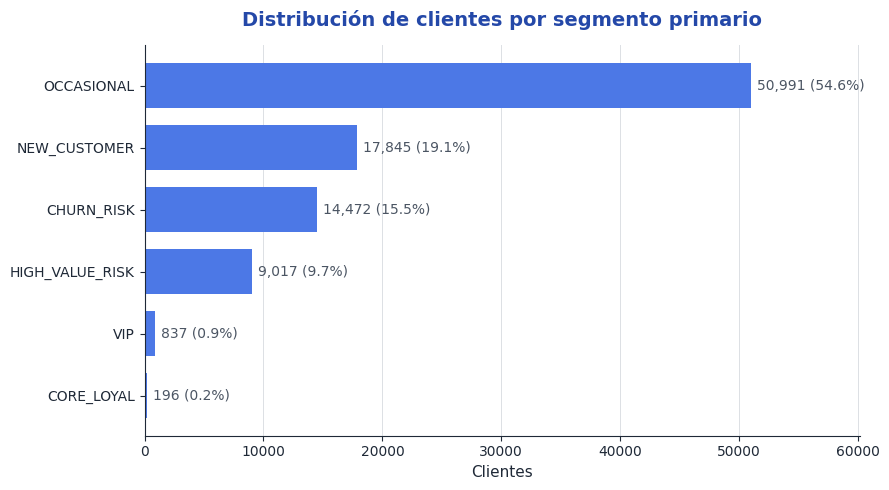

In [13]:
plot_df = customer_primary_segment_summary.sort_values("n_customers", ascending=True).copy()

fig, ax = plt.subplots(figsize=(9, 5), facecolor=TP_COLORS["white"])
ax.set_facecolor(TP_COLORS["white"])

ax.barh(
    plot_df["customer_segment_primary"],
    plot_df["n_customers"],
    color=TP_COLORS["blue_secondary"],
    edgecolor="none",
    height=0.72,
)

ax.set_title(
    "Distribución de clientes por segmento primario",
    fontsize=14,
    fontweight="bold",
    color=TP_COLORS["blue_primary"],
    pad=14
)
ax.set_xlabel("Clientes", color=TP_COLORS["gray_dark"], fontsize=11)
ax.set_ylabel("")

for side in ["top", "right"]:
    ax.spines[side].set_visible(False)
ax.spines["left"].set_color(TP_COLORS["gray_dark"])
ax.spines["bottom"].set_color(TP_COLORS["gray_dark"])

ax.tick_params(axis="x", colors=TP_COLORS["gray_dark"], labelsize=10)
ax.tick_params(axis="y", colors=TP_COLORS["gray_dark"], labelsize=10)

ax.xaxis.grid(True, linestyle="-", linewidth=0.7, color=TP_COLORS["gray_muted"], alpha=0.75)
ax.set_axisbelow(True)

max_val = plot_df["n_customers"].max()

for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.text(
        row["n_customers"] + max_val * 0.01,
        i,
        f'{row["n_customers"]:,.0f} ({row["share_pct"]:.1%})',
        va="center",
        ha="left",
        color=TP_COLORS["gray_text"],
        fontsize=10
    )

ax.set_xlim(0, max_val * 1.18)

plt.tight_layout()
plt.show()

In [14]:
customer_flag_summary

,flag_name,n_customers,share_pct
0,HIGH_VALUE,18751,0.200850
1,FRICTION_RISK,93358,1.000000
2,CHURN_SIGNAL,23489,0.251601


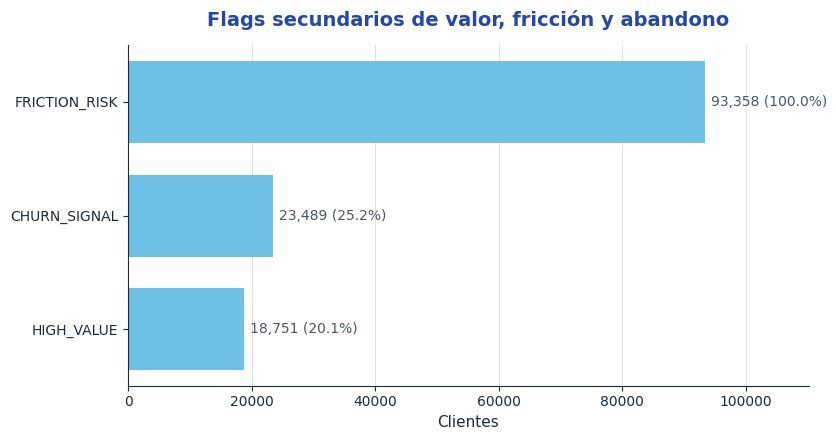

In [15]:
plot_df = customer_flag_summary.sort_values("n_customers", ascending=True).copy()

fig, ax = plt.subplots(figsize=(8.5, 4.5), facecolor=TP_COLORS["white"])
ax.set_facecolor(TP_COLORS["white"])

ax.barh(
    plot_df["flag_name"],
    plot_df["n_customers"],
    color=TP_COLORS["blue_soft"],
    edgecolor="none",
    height=0.72,
)

ax.set_title(
    "Flags secundarios de valor, fricción y abandono",
    fontsize=14,
    fontweight="bold",
    color=TP_COLORS["blue_primary"],
    pad=14
)
ax.set_xlabel("Clientes", color=TP_COLORS["gray_dark"], fontsize=11)
ax.set_ylabel("")

for side in ["top", "right"]:
    ax.spines[side].set_visible(False)
ax.spines["left"].set_color(TP_COLORS["gray_dark"])
ax.spines["bottom"].set_color(TP_COLORS["gray_dark"])

ax.tick_params(axis="x", colors=TP_COLORS["gray_dark"], labelsize=10)
ax.tick_params(axis="y", colors=TP_COLORS["gray_dark"], labelsize=10)

ax.xaxis.grid(True, linestyle="-", linewidth=0.7, color=TP_COLORS["gray_muted"], alpha=0.75)
ax.set_axisbelow(True)

max_val = plot_df["n_customers"].max()

for i, (_, row) in enumerate(plot_df.iterrows()):
    ax.text(
        row["n_customers"] + max_val * 0.01,
        i,
        f'{row["n_customers"]:,.0f} ({row["share_pct"]:.1%})',
        va="center",
        ha="left",
        color=TP_COLORS["gray_text"],
        fontsize=10
    )

ax.set_xlim(0, max_val * 1.18)

plt.tight_layout()
plt.show()

## 2. Arquitectura y flujo lógico del recomendador en tiempo real (Q4)

### Objetivo
Cuando un cliente visite la página web, el sistema debe recomendar productos en función de:
- su perfil,
- su historial de compras,
- y la lógica del catálogo.

In [16]:
recommender_architecture = pd.DataFrame({
    "layer": [
        "Client Profile API",
        "Customer 360 Feature Store",
        "Candidate Generator",
        "Ranking Engine",
        "Serving Layer",
        "Feedback Loop",
    ],
    "role": [
        "Resuelve identidad y perfil del cliente",
        "Almacena el customer_360 y señales operativas",
        "Construye candidatos por afinidad, historial y segmento",
        "Prioriza productos con score explicable",
        "Entrega top-N recomendaciones en tiempo real",
        "Registra clics y compras para mejora continua",
    ]
})

recommender_architecture

,layer,role
0,Client Profile API,Resuelve identidad y perfil del cliente
1,Customer 360 Feature Store,Almacena el customer_360 y señales operativas
2,Candidate Generator,"Construye candidatos por afinidad, historial y..."
3,Ranking Engine,Prioriza productos con score explicable
4,Serving Layer,Entrega top-N recomendaciones en tiempo real
5,Feedback Loop,Registra clics y compras para mejora continua


In [17]:
recommender_flow = pd.DataFrame({
    "step": [1, 2, 3, 4, 5, 6],
    "description": [
        "Identificar al cliente autenticado",
        "Consultar customer_segment_primary, flags y categoría favorita",
        "Leer purchase_history_summary e historial reciente",
        "Generar candidatos por segmento, categoría y popularidad",
        "Aplicar ranking y filtros de exclusión",
        "Servir top-N productos y registrar feedback",
    ]
})

recommender_flow

,step,description
0,1,Identificar al cliente autenticado
1,2,"Consultar customer_segment_primary, flags y ca..."
2,3,Leer purchase_history_summary e historial reci...
3,4,"Generar candidatos por segmento, categoría y p..."
4,5,Aplicar ranking y filtros de exclusión
5,6,Servir top-N productos y registrar feedback


In [18]:
ranking_formula = pd.DataFrame({
    "component": [
        "Segment affinity",
        "Category affinity",
        "Popularity",
        "Recent purchase penalty",
        "Friction-aware adjustment",
    ],
    "logic": [
        "Qué compran clientes del mismo segmento principal",
        "Qué compra más este cliente en su categoría favorita",
        "Qué productos convierten mejor en general",
        "Evita recomendar lo ya comprado recientemente",
        "Si hay FRICTION_RISK, prioriza opciones más seguras y relevantes",
    ]
})

ranking_formula

,component,logic
0,Segment affinity,Qué compran clientes del mismo segmento principal
1,Category affinity,Qué compra más este cliente en su categoría fa...
2,Popularity,Qué productos convierten mejor en general
3,Recent purchase penalty,Evita recomendar lo ya comprado recientemente
4,Friction-aware adjustment,"Si hay FRICTION_RISK, prioriza opciones más se..."


### Decisión ejecutiva del punto 4

La recomendación debe basarse en un esquema híbrido y explicable:
- segmento principal,
- flags de riesgo,
- historial resumido,
- y afinidad por categoría.

Este enfoque es más entendible para negocio y deja una base para evolucionar a un sistema agentic más adelante.

### 3. Priorización geográfica para tienda insignia(Q5)

#### Supuesto
Como el dataset no contiene tráfico físico, renta comercial ni coordenada exacta de ubicación, la decisión se aproxima con evidencia comercial digital:
- ingresos
- número de órdenes
- base de clientes
- ticket promedio

In [19]:
city_priority.head(10)

,customer_state,customer_city,n_orders,n_customers,total_revenue,avg_order_value,total_items,revenue_norm,orders_norm,customers_norm,aov_norm,city_priority_score
0,SP,sao paulo,15045,14528,1859556.83,123.599656,17400,1.000000,1.000000,1.000000,0.053773,0.905377
1,RJ,rio de janeiro,6601,6361,955573.97,144.762001,7592,0.513870,0.438713,0.437805,0.063417,0.434823
2,MG,belo horizonte,2697,2606,346039.04,128.305169,3087,0.186084,0.179208,0.179321,0.055917,0.169996
3,DF,brasilia,2071,2013,295814.72,142.836659,2341,0.159076,0.137596,0.138501,0.062539,0.139937
4,PB,pianco,1,1,2200.00,2200.000000,1,0.001180,0.000000,0.000000,1.000000,0.100531
5,PA,nova esperanca do piria,1,1,2199.00,2199.000000,1,0.001180,0.000000,0.000000,0.999544,0.100485
6,PR,curitiba,1489,1434,205999.33,138.347435,1727,0.110776,0.098910,0.098644,0.060494,0.100355
7,AL,sao sebastiao,1,1,2159.98,2159.980000,2,0.001159,0.000000,0.000000,0.981763,0.098698
8,SP,campinas,1406,1363,184657.87,131.335612,1626,0.099299,0.093393,0.093756,0.057298,0.092514
9,MG,engenheiro navarro,1,1,1997.00,1997.000000,1,0.001071,0.000000,0.000000,0.907492,0.091231


In [20]:
city_criteria = pd.DataFrame({
    "criterion": [
        "Total revenue",
        "Number of orders",
        "Unique customers",
        "Average order value",
    ],
    "business_meaning": [
        "Escala económica total",
        "Consistencia de demanda",
        "Tamaño de base activa",
        "Calidad del consumo promedio",
    ]
})

city_criteria

,criterion,business_meaning
0,Total revenue,Escala económica total
1,Number of orders,Consistencia de demanda
2,Unique customers,Tamaño de base activa
3,Average order value,Calidad del consumo promedio


In [21]:
top_city.to_frame().T

,customer_state,customer_city,n_orders,n_customers,total_revenue,avg_order_value,total_items,revenue_norm,orders_norm,customers_norm,aov_norm,city_priority_score
0,SP,sao paulo,15045,14528,1859556.83,123.599656,17400,1.0,1.0,1.0,0.053773,0.905377


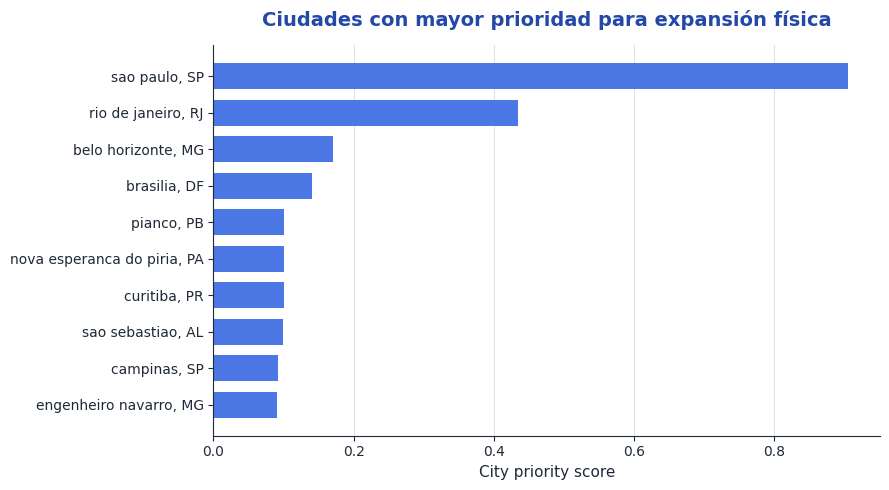

In [22]:
plot_df = city_priority.head(10).sort_values("city_priority_score", ascending=True).copy()
plot_df["city_label"] = plot_df["customer_city"] + ", " + plot_df["customer_state"]

fig, ax = plt.subplots(figsize=(9, 5), facecolor=TP_COLORS["white"])
ax.set_facecolor(TP_COLORS["white"])

ax.barh(
    plot_df["city_label"],
    plot_df["city_priority_score"],
    color=TP_COLORS["blue_secondary"],
    edgecolor="none",
    height=0.72,
)

ax.set_title(
    "Ciudades con mayor prioridad para expansión física",
    fontsize=14,
    fontweight="bold",
    color=TP_COLORS["blue_primary"],
    pad=14
)
ax.set_xlabel("City priority score", color=TP_COLORS["gray_dark"], fontsize=11)
ax.set_ylabel("")

for side in ["top", "right"]:
    ax.spines[side].set_visible(False)
ax.spines["left"].set_color(TP_COLORS["gray_dark"])
ax.spines["bottom"].set_color(TP_COLORS["gray_dark"])

ax.tick_params(axis="x", colors=TP_COLORS["gray_dark"], labelsize=10)
ax.tick_params(axis="y", colors=TP_COLORS["gray_dark"], labelsize=10)

ax.xaxis.grid(True, linestyle="-", linewidth=0.7, color=TP_COLORS["gray_muted"], alpha=0.75)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

### Conslusión (Q5)

La ciudad priorizada debe ser aquella que combine:
- mayor escala comercial,
- mayor base de clientes,
- y ticket promedio competitivo.


### Conslusión Notebook

- Q3 se resuelve mejor con una segmentación híbrida de segmento principal + flags.
- Q4 debe consumir `customer_360_features.csv` como base del recomendador.
- Q5 puede sostenerse con una priorización geográfica basada en revenue, órdenes, clientes y ticket.